## Dataset Overview

Welcome to the cutting edge of manufacturing data science! Proprietary Quality Assurance (QA) data from Electric Vehicle (EV) battery gigafactories is heavily guarded. This dataset provides a highly realistic, causally linked synthetic environment mirroring a 2026 Lithium-Ion manufacturing line.
It tracks 20,000 individual battery cells from raw material supplier input, through physical production metrics (like Anode Overhang and Electrolyte Volume), down to their final electrical testing (Internal Resistance, Capacity, and Cycle Retention).

## Problem Statement

Need to find the type of error occurs in the battery

## Target Columns :- 
#### Defect Types :-
1. Critical Resistance 
2. High Internal Resistance
3. Low Capacity
4. None
5. Poor Retention
6. Severe Capacity Fade
7. Short Circuit Risk (Overhang)

## Dataset Columns :-

![Dataset Columns](ev_col.PNG)

## Libraries Import

In [1]:
# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# EDA Libraries
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# machine Learning Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Model Evaluation Libraries
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Pickle File
import pickle


## Data Import

In [2]:
df = pd.read_csv("C:/Users/Suyash Kadu/Desktop/CODING/NOTES/Machine Learning/ev_battery_qc_data.csv")
df

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,NaN,Scrap
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,NaN,Grade A
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,NaN,Grade A
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,NaN,Grade A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,CELL-009308,BTH-0499,Line_1,Night,VoltIndustries,20.31,0.129,14.98,14.99,4997.0,96.58,NaN,NaN,Grade A
19996,CELL-011250,BTH-0499,Line_3,Evening,VoltIndustries,21.52,0.119,14.95,14.50,5031.0,97.17,NaN,NaN,Grade B
19997,CELL-003841,BTH-0499,Line_2,Morning,ChemCorp,24.40,0.106,15.05,13.82,4993.0,97.34,NaN,NaN,Scrap
19998,CELL-000715,BTH-0499,Line_1,Evening,VoltIndustries,23.87,0.151,15.06,15.28,4970.0,97.09,High Internal Resistance,NaN,Grade B


## Checking Data Quality

In [3]:
df.drop(["Cell_ID", "Batch_ID", "Production_Line", "Supplier", "Inspector_Comment", "QC_Grade"], axis=1, inplace=True)

In [4]:
df

,Shift,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type
0,Evening,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention
1,Night,22.38,0.126,14.96,14.70,4989.0,97.35,NaN
2,Night,20.18,0.135,14.97,13.80,5032.0,96.77,NaN
3,Morning,24.30,0.162,14.84,14.65,5042.0,95.88,NaN
4,Evening,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance
...,...,...,...,...,...,...,...,...
19995,Night,20.31,0.129,14.98,14.99,4997.0,96.58,NaN
19996,Evening,21.52,0.119,14.95,14.50,5031.0,97.17,NaN
19997,Morning,24.40,0.106,15.05,13.82,4993.0,97.34,NaN
19998,Evening,23.87,0.151,15.06,15.28,4970.0,97.09,High Internal Resistance


[4 3 1 5 0 6 2]


In [5]:
df.describe()

,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct
count,19400.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.157409,0.137498,14.979050,14.280926,4988.398450,96.801533
std,1.890930,0.020991,0.119464,0.705987,48.205605,1.170866
min,16.260000,0.057000,14.430000,11.900000,4576.000000,90.210000
25%,21.860000,0.123000,14.910000,13.790000,4971.000000,96.350000
50%,23.250000,0.138000,14.990000,14.200000,4995.000000,96.940000
75%,24.490000,0.152000,15.060000,14.680000,5017.000000,97.510000
max,29.790000,0.219000,15.370000,17.640000,5120.000000,100.840000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Shift                     20000 non-null  object 
 1   Ambient_Temp_C            19400 non-null  float64
 2   Anode_Overhang_mm         20000 non-null  float64
 3   Electrolyte_Volume_ml     20000 non-null  float64
 4   Internal_Resistance_mOhm  20000 non-null  float64
 5   Capacity_mAh              20000 non-null  float64
 6   Retention_50Cycle_Pct     20000 non-null  float64
 7   Defect_Type               3501 non-null   object 
dtypes: float64(6), object(2)
memory usage: 1.2+ MB


In [7]:
df.isnull().sum()

Shift                           0
Ambient_Temp_C                600
Anode_Overhang_mm               0
Electrolyte_Volume_ml           0
Internal_Resistance_mOhm        0
Capacity_mAh                    0
Retention_50Cycle_Pct           0
Defect_Type                 16499
dtype: int64

In [8]:
df["Ambient_Temp_C"] = df["Ambient_Temp_C"].fillna(df["Ambient_Temp_C"].median())
df["Defect_Type"] = df["Defect_Type"].fillna("None")

## Univariate Analysis

In [9]:
def continuous_value(col):
    a = pd.DataFrame({
        "Mean": [df[col].mean()],
        "Mode": [df[col].mode()],
        "Median": [df[col].median()],
        "Minimum": [df[col].min()],
        "Maximum": [df[col].max()]
    })

    print(a)
def continuous_value_graph(col):
    print(f"Visualization for : {col}")
    plt.figure(figsize=(5, 5))
    fig, ax = plt.subplots(1,2)
    sns.histplot(df[col], color="Skyblue", ax= ax[0])
    sns.kdeplot(df[col], fill=True, color="Lightblue", ax= ax[1])
    plt.tight_layout()
    plt.show()

def categorical_value(col):
    a = pd.DataFrame({
        "Unique Value Count": [df[col].nunique()],
        "Value Count": [df[col].value_counts().sum()]
    })

    print(a)

def categorical_value_graph(col):
    sns.countplot(df[col], color='Skyblue')
    plt.show()

---------------------------------------------------------------------------------------------------------------------------------------
AMBIENT_TEMP_C
---------------------------------------------------------------------------------------------------------------------------------------
        Mean                                             Mode  Median  \
0  23.160187  0    23.25
Name: Ambient_Temp_C, dtype: float64   23.25   

   Minimum  Maximum  
0    16.26    29.79  
Visualization for : Ambient_Temp_C


<Figure size 500x500 with 0 Axes>

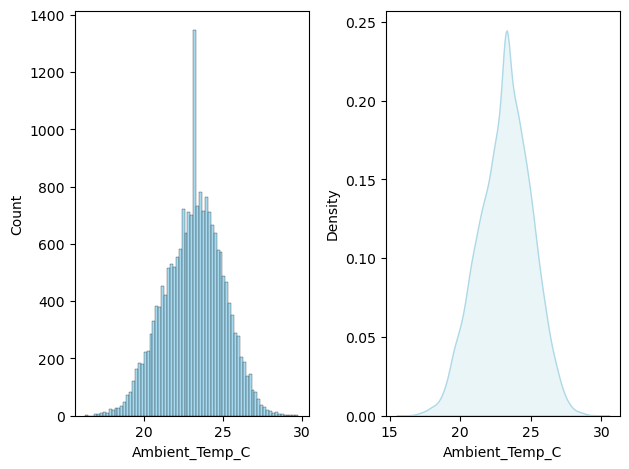

---------------------------------------------------------------------------------------------------------------------------------------
ANODE_OVERHANG_MM
---------------------------------------------------------------------------------------------------------------------------------------
       Mean                                               Mode  Median  \
0  0.137498  0    0.132
Name: Anode_Overhang_mm, dtype: flo...   0.138   

   Minimum  Maximum  
0    0.057    0.219  
Visualization for : Anode_Overhang_mm


<Figure size 500x500 with 0 Axes>

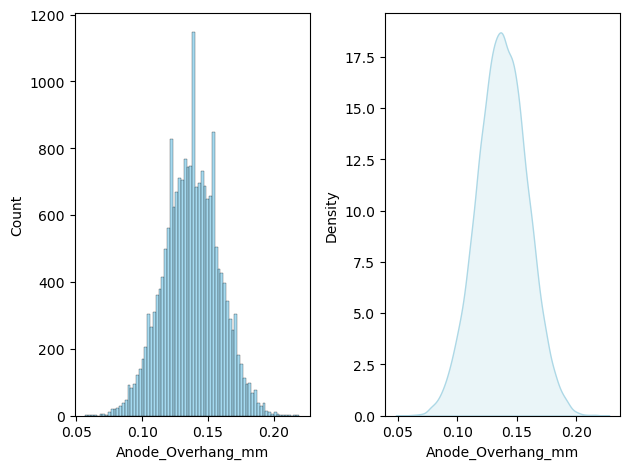

---------------------------------------------------------------------------------------------------------------------------------------
ELECTROLYTE_VOLUME_ML
---------------------------------------------------------------------------------------------------------------------------------------
       Mean                                               Mode  Median  \
0  14.97905  0    15.0
Name: Electrolyte_Volume_ml, dtype: ...   14.99   

   Minimum  Maximum  
0    14.43    15.37  
Visualization for : Electrolyte_Volume_ml


<Figure size 500x500 with 0 Axes>

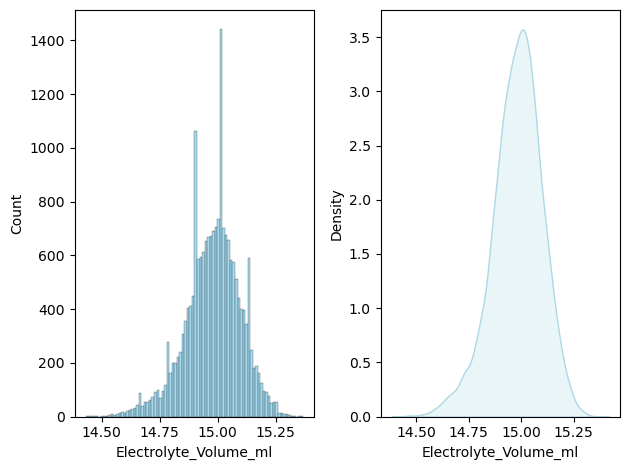

---------------------------------------------------------------------------------------------------------------------------------------
INTERNAL_RESISTANCE_MOHM
---------------------------------------------------------------------------------------------------------------------------------------
        Mean                                               Mode  Median  \
0  14.280926  0    14.17
Name: Internal_Resistance_mOhm, dty...    14.2   

   Minimum  Maximum  
0     11.9    17.64  
Visualization for : Internal_Resistance_mOhm


<Figure size 500x500 with 0 Axes>

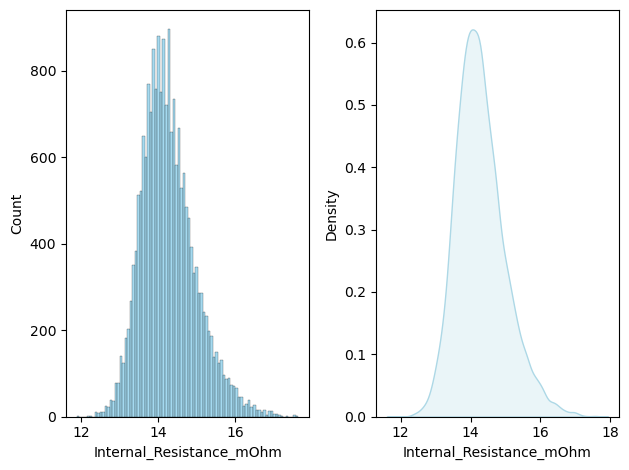

---------------------------------------------------------------------------------------------------------------------------------------
CAPACITY_MAH
---------------------------------------------------------------------------------------------------------------------------------------
         Mean                                            Mode  Median  \
0  4988.39845  0    5006.0
Name: Capacity_mAh, dtype: float64  4995.0   

   Minimum  Maximum  
0   4576.0   5120.0  
Visualization for : Capacity_mAh


<Figure size 500x500 with 0 Axes>

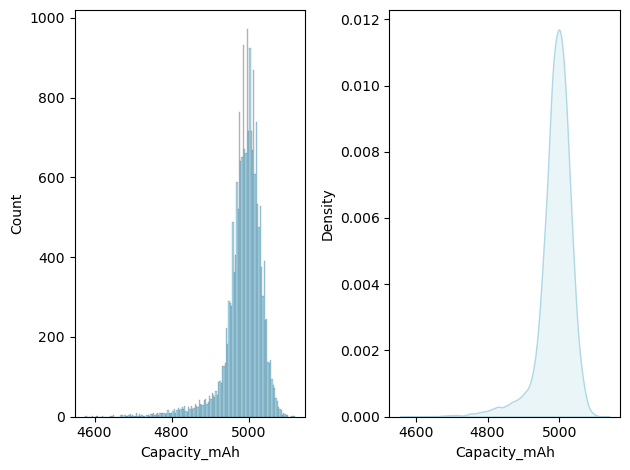

---------------------------------------------------------------------------------------------------------------------------------------
RETENTION_50CYCLE_PCT
---------------------------------------------------------------------------------------------------------------------------------------
        Mean                                               Mode  Median  \
0  96.801533  0    96.89
Name: Retention_50Cycle_Pct, dtype:...   96.94   

   Minimum  Maximum  
0    90.21   100.84  
Visualization for : Retention_50Cycle_Pct


<Figure size 500x500 with 0 Axes>

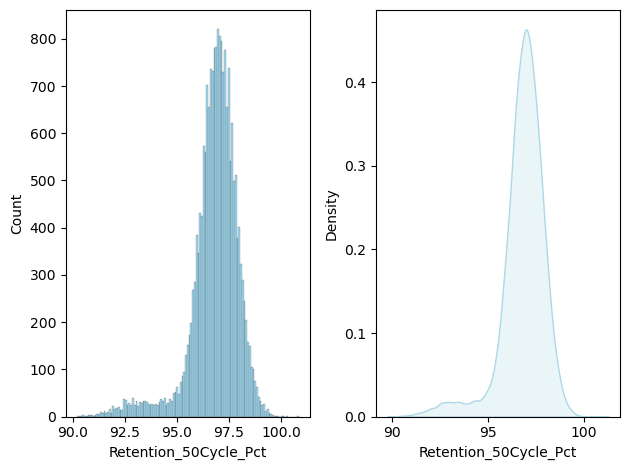

In [10]:
for i in ("Ambient_Temp_C", "Anode_Overhang_mm", "Electrolyte_Volume_ml", "Internal_Resistance_mOhm", "Capacity_mAh", 
          "Retention_50Cycle_Pct"):
    print("---"*45)
    print(i.upper())
    print("---"*45)

    continuous_value(i)
    continuous_value_graph(i)

---------------------------------------------------------------------------------------------------------------------------------------
SHIFT
---------------------------------------------------------------------------------------------------------------------------------------
   Unique Value Count  Value Count
0                   3        20000


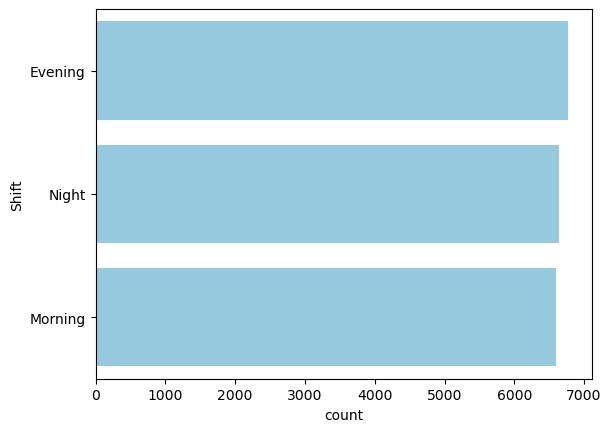

---------------------------------------------------------------------------------------------------------------------------------------
DEFECT_TYPE
---------------------------------------------------------------------------------------------------------------------------------------
   Unique Value Count  Value Count
0                   7        20000


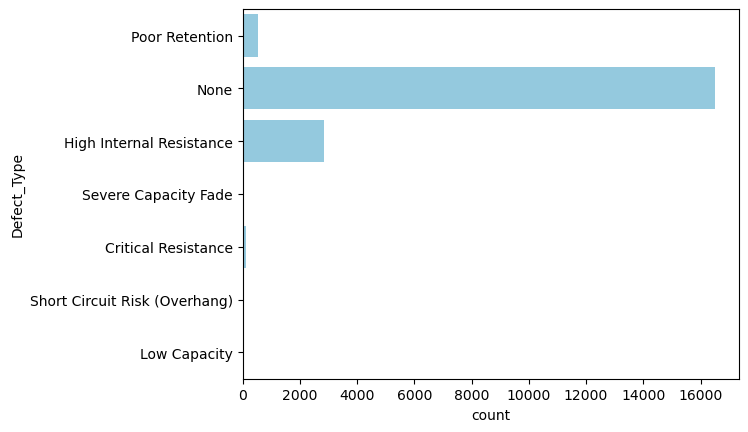

In [11]:
for i in ("Shift", "Defect_Type"):
    print("---"*45)
    print(i.upper())
    print("---"*45)

    categorical_value(i)
    categorical_value_graph(i)
    

## Bivariate Analysis

In [12]:
def bivariate_analysis_shift(col):
    bar = df.groupby("Shift")[col].mean().sort_values()
    b = plt.barh(bar.index, bar.values, color="Lightblue")
    plt.xlabel(f"Average {col}")
    plt.show()

def bivariate_analysis_defect(col):
    bar = df.groupby("Defect_Type")[col].mean().sort_values()
    b = plt.barh(bar.index, bar.values, color="Lightblue")
    plt.xlabel(f"Average {col}")
    plt.show()

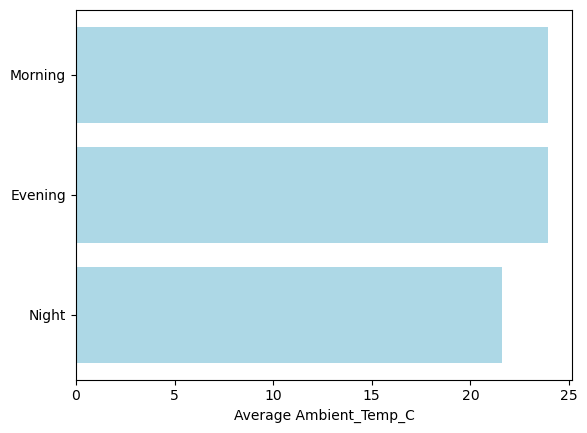

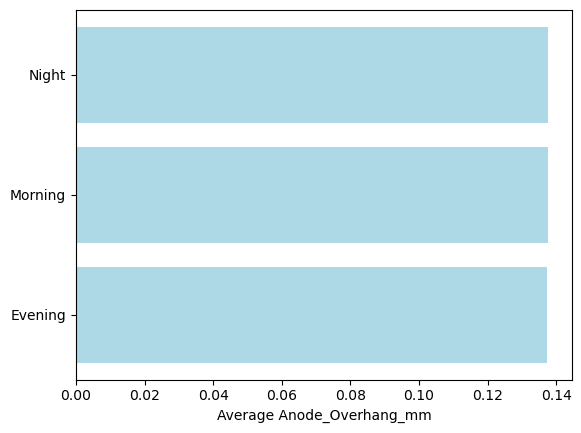

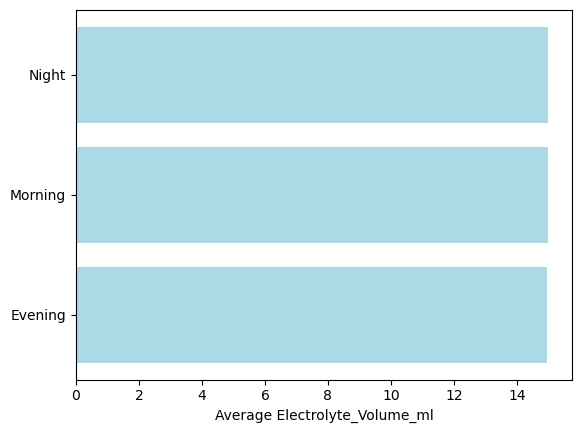

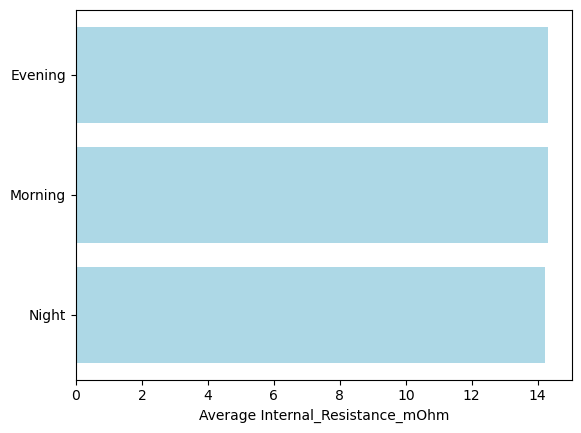

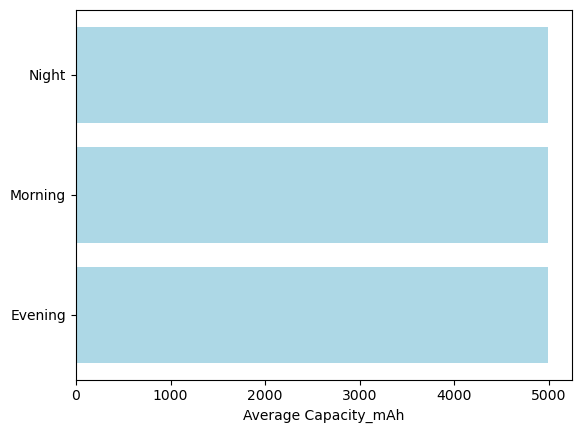

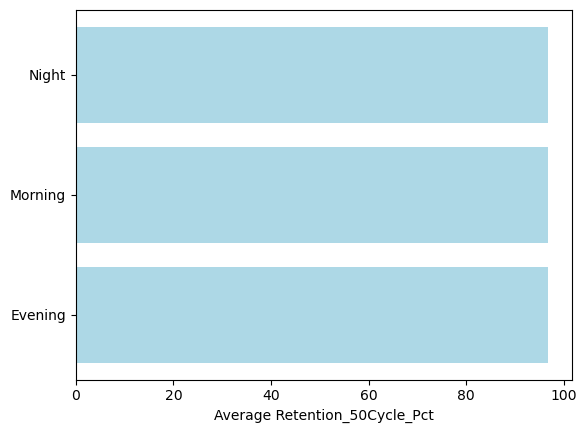

In [13]:
for i in ("Ambient_Temp_C", "Anode_Overhang_mm", "Electrolyte_Volume_ml", "Internal_Resistance_mOhm", "Capacity_mAh", 
          "Retention_50Cycle_Pct"):
    bivariate_analysis_shift(i)

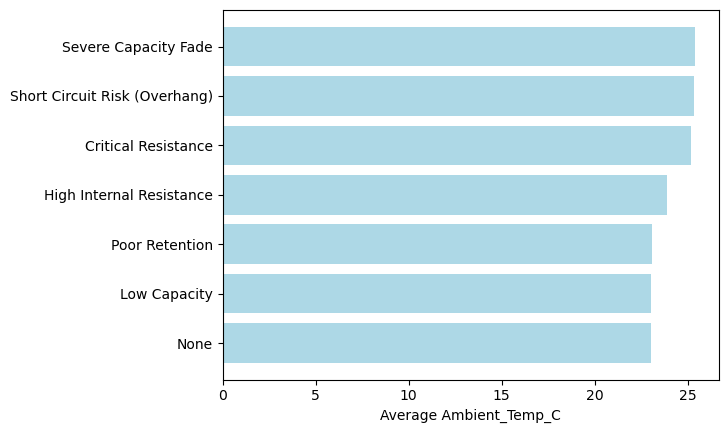

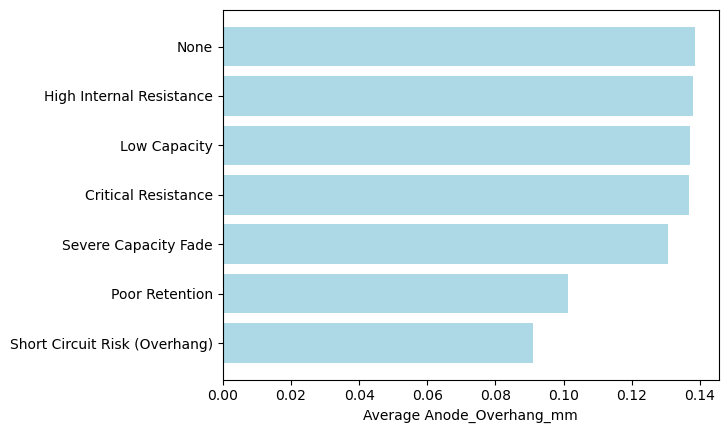

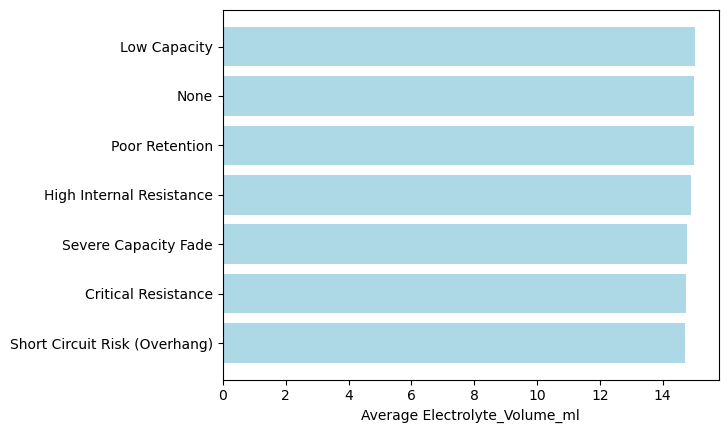

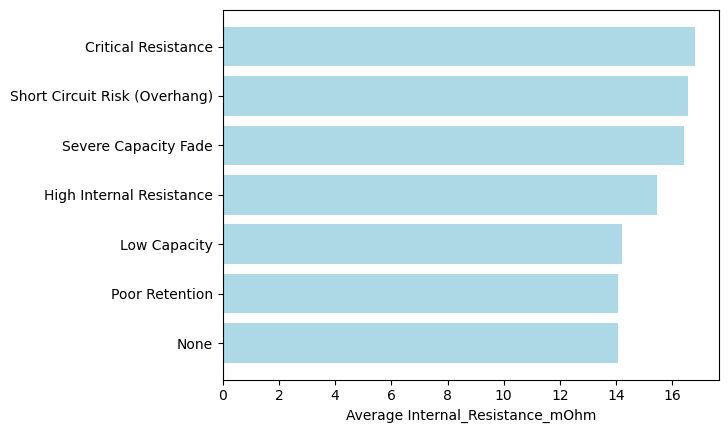

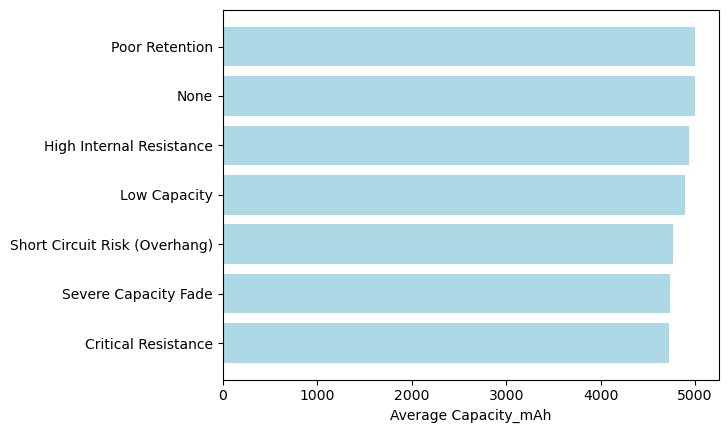

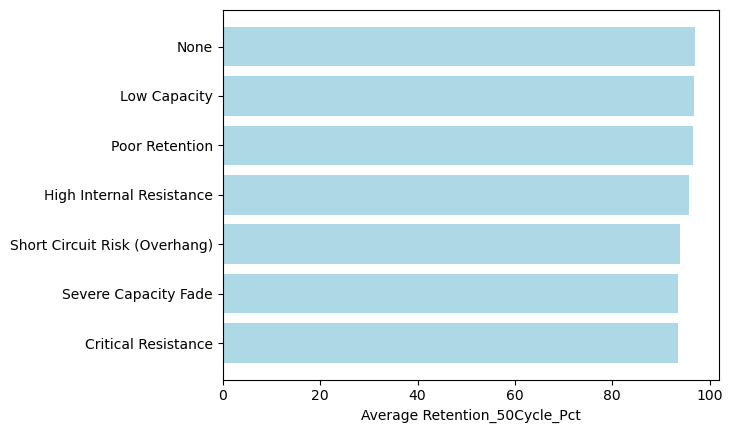

In [14]:
for i in ("Ambient_Temp_C", "Anode_Overhang_mm", "Electrolyte_Volume_ml", "Internal_Resistance_mOhm", "Capacity_mAh", 
          "Retention_50Cycle_Pct"):
    bivariate_analysis_defect(i)

## Multivariate Analysis

In [15]:
df_1 = df[["Ambient_Temp_C", "Anode_Overhang_mm", "Electrolyte_Volume_ml", "Internal_Resistance_mOhm", "Capacity_mAh", 
          "Retention_50Cycle_Pct"]]
df_1.cov()

,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct
Ambient_Temp_C,3.468591,-0.000162,-0.063389,0.218523,-15.386744,-0.274886
Anode_Overhang_mm,-0.000162,0.000441,-0.000003,-0.000046,0.001051,0.000020
Electrolyte_Volume_ml,-0.063389,-0.000003,0.014272,-0.027413,1.838773,0.036855
Internal_Resistance_mOhm,0.218523,-0.000046,-0.027413,0.498417,-18.613615,-0.344989
Capacity_mAh,-15.386744,0.001051,1.838773,-18.613615,2323.780377,27.569095
Retention_50Cycle_Pct,-0.274886,0.000020,0.036855,-0.344989,27.569095,1.370927


<Axes: >

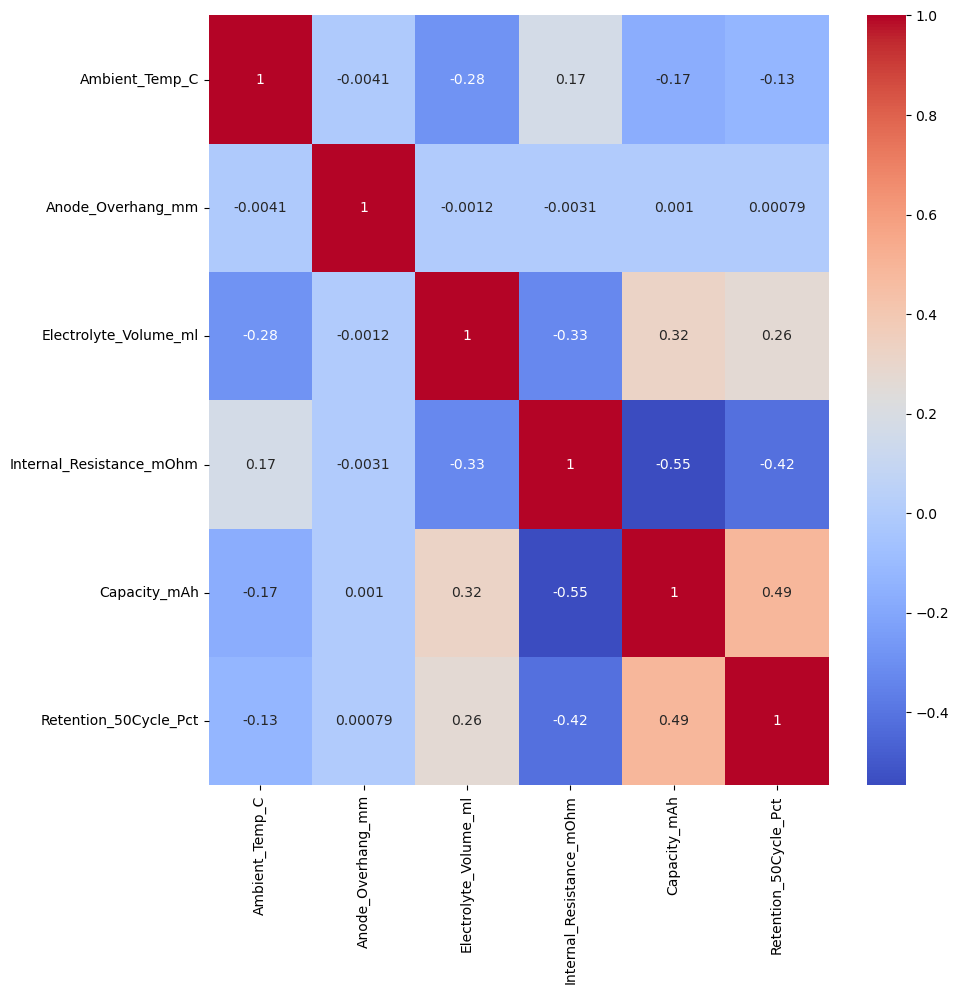

In [16]:
plt.figure(figsize=(10,10))
sns.heatmap(df_1.corr(), cmap="coolwarm", annot = True)

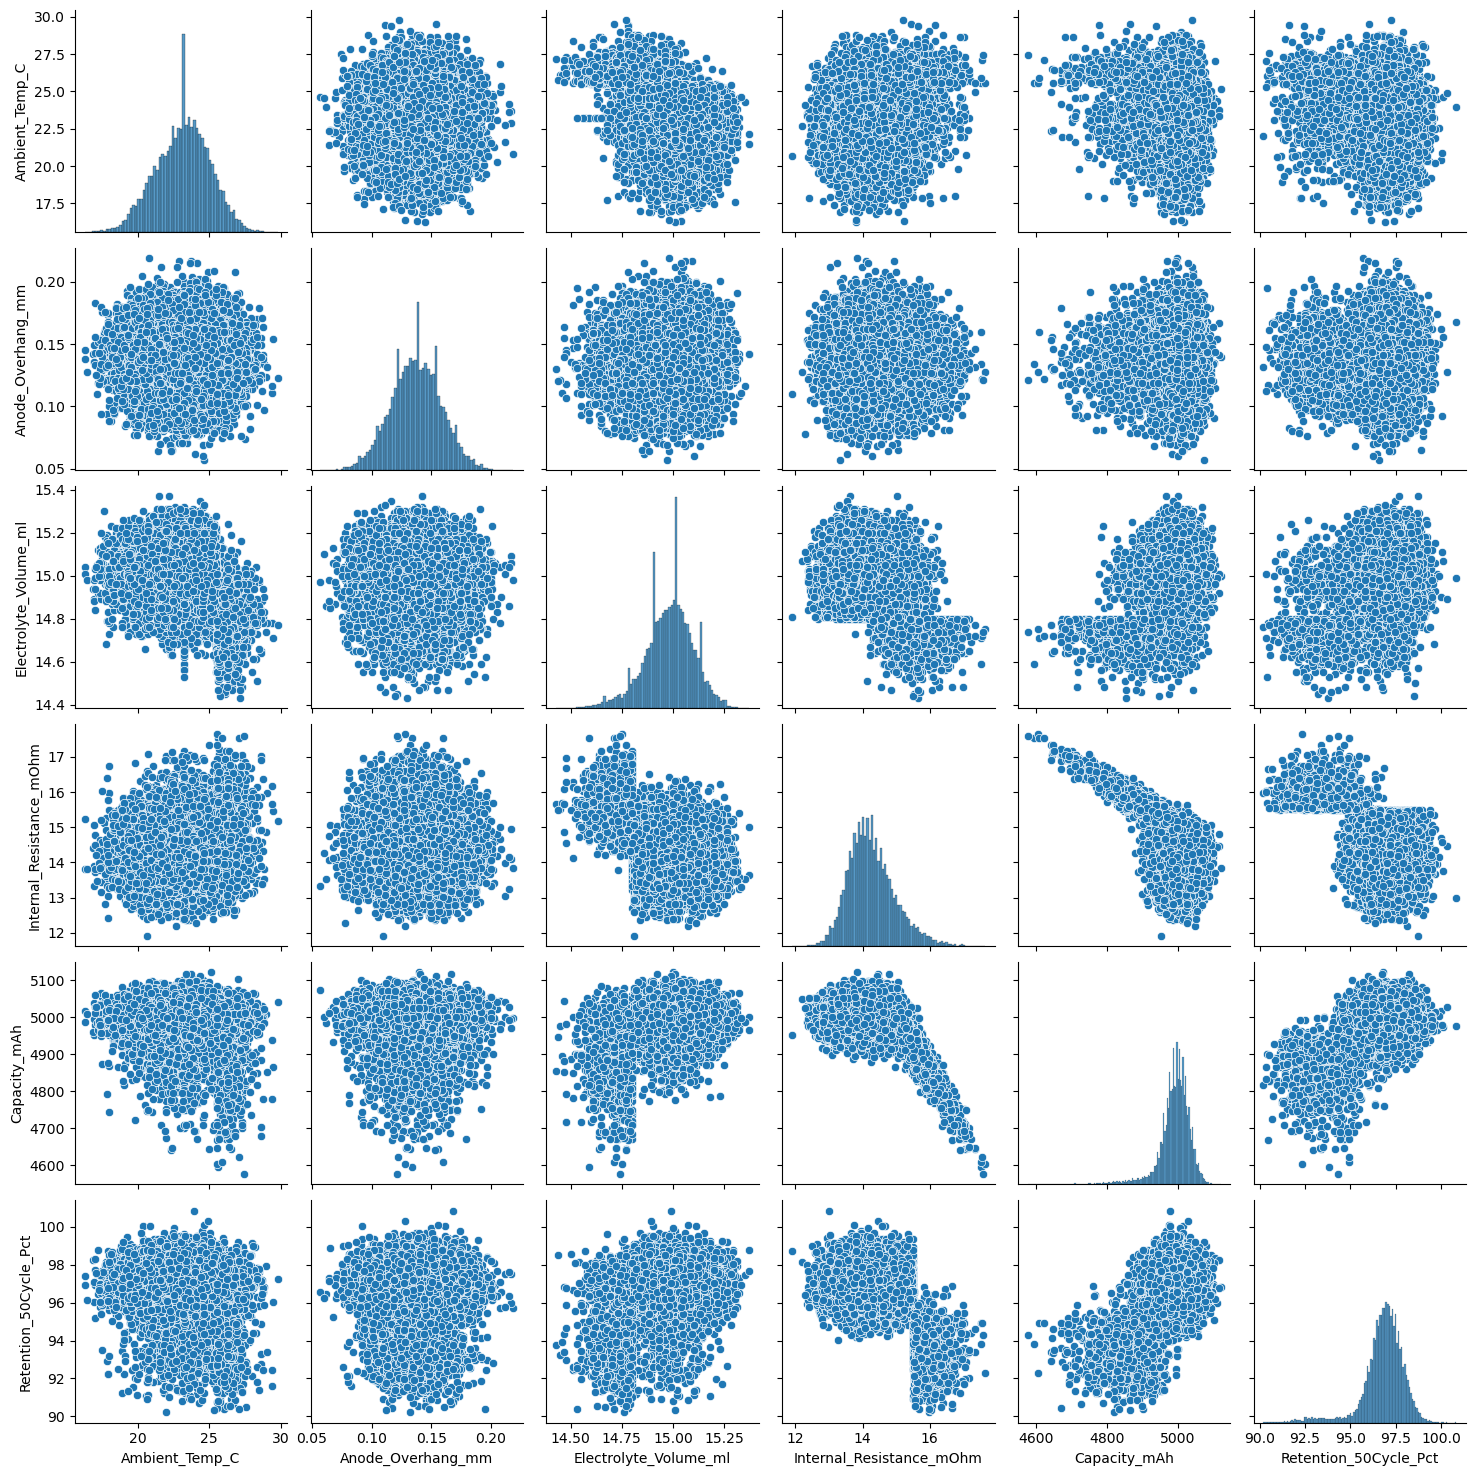

In [17]:
sns.pairplot(df[["Ambient_Temp_C", "Anode_Overhang_mm", "Electrolyte_Volume_ml", "Internal_Resistance_mOhm", "Capacity_mAh", 
          "Retention_50Cycle_Pct"]])

## Findling Outliers

In [18]:
def continuous_data_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1

    upper_band = q3 + iqr*1.5
    lower_band = q1 - iqr*1.5
    outlier = (df[col] > upper_band) | (df[col] < lower_band)
    outliers_sum = outlier.sum()
    print(f"Find {outliers_sum} outliers for column {col}")

    if outliers_sum > 0:
        col_median = df[col].median()
        df.loc[outlier, col] = col_median
        print(f"Outliers replaced with median: {col_median}")

    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col} (Post-Handling)")
    plt.show()
    

Find 114 outliers for column Ambient_Temp_C
Outliers replaced with median: 23.25


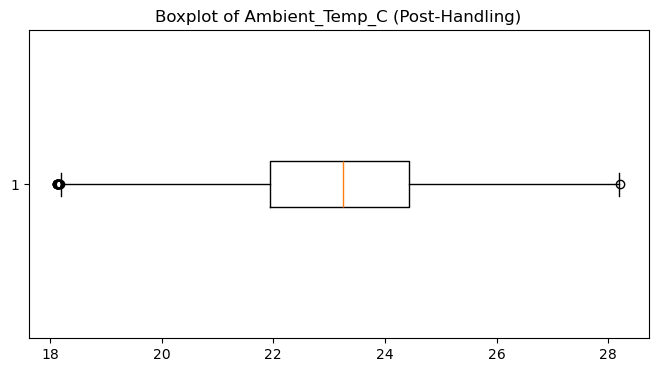

Find 96 outliers for column Anode_Overhang_mm
Outliers replaced with median: 0.138


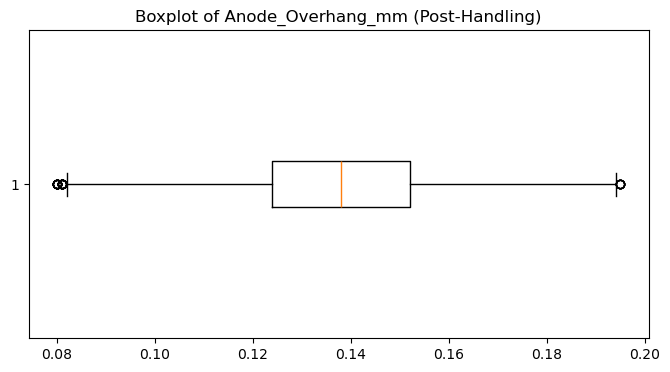

Find 401 outliers for column Electrolyte_Volume_ml
Outliers replaced with median: 14.99


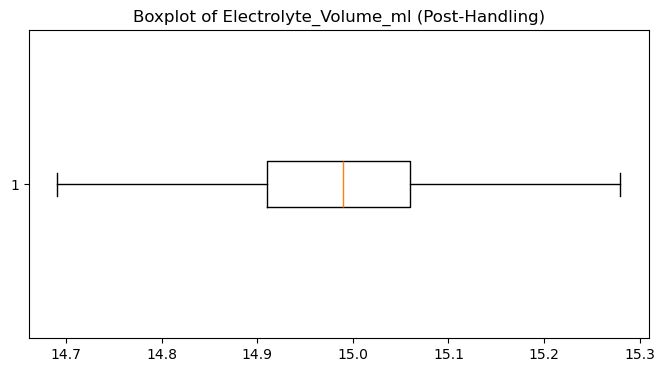

Find 415 outliers for column Internal_Resistance_mOhm
Outliers replaced with median: 14.2


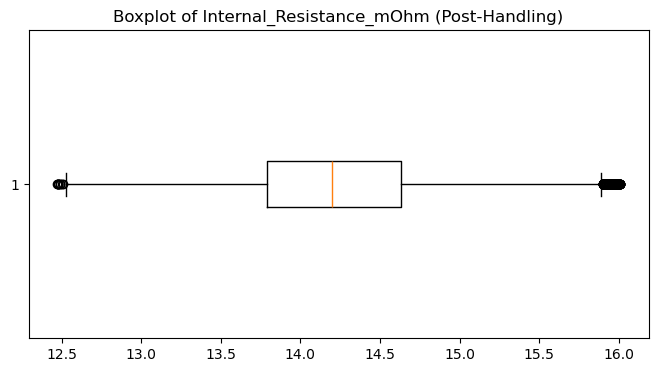

Find 998 outliers for column Capacity_mAh
Outliers replaced with median: 4995.0


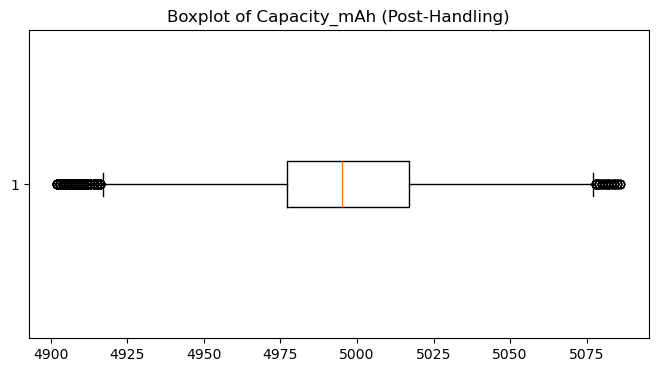

Find 1022 outliers for column Retention_50Cycle_Pct
Outliers replaced with median: 96.94


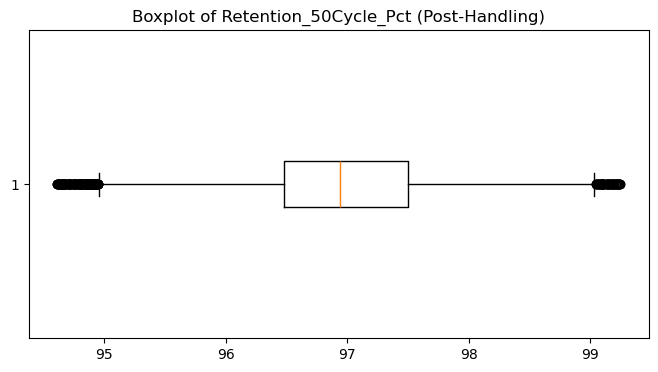

In [19]:
for i in (["Ambient_Temp_C", "Anode_Overhang_mm", "Electrolyte_Volume_ml", "Internal_Resistance_mOhm", "Capacity_mAh", 
          "Retention_50Cycle_Pct"]):
    continuous_data_outliers(i)

In [20]:
df

,Shift,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type
0,Evening,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention
1,Night,22.38,0.126,14.96,14.70,4989.0,97.35,None
2,Night,20.18,0.135,14.97,13.80,5032.0,96.77,None
3,Morning,24.30,0.162,14.84,14.65,5042.0,95.88,None
4,Evening,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance
...,...,...,...,...,...,...,...,...
19995,Night,20.31,0.129,14.98,14.99,4997.0,96.58,None
19996,Evening,21.52,0.119,14.95,14.50,5031.0,97.17,None
19997,Morning,24.40,0.106,15.05,13.82,4993.0,97.34,None
19998,Evening,23.87,0.151,15.06,15.28,4970.0,97.09,High Internal Resistance


## Encoding 

In [21]:
le = LabelEncoder()
le_array = le.fit_transform(df["Shift"])
df["Shift"] = pd.DataFrame(le_array)
df

le = LabelEncoder()
le_array = le.fit_transform(df["Defect_Type"])
df["Defect_Type"] = pd.DataFrame(le_array)
df

,Shift,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type
0,0,20.76,0.108,14.81,14.01,4980.0,97.79,4
1,2,22.38,0.126,14.96,14.70,4989.0,97.35,3
2,2,20.18,0.135,14.97,13.80,5032.0,96.77,3
3,1,24.30,0.162,14.84,14.65,5042.0,95.88,3
4,0,22.22,0.130,14.89,15.04,4943.0,97.74,1
...,...,...,...,...,...,...,...,...
19995,2,20.31,0.129,14.98,14.99,4997.0,96.58,3
19996,0,21.52,0.119,14.95,14.50,5031.0,97.17,3
19997,1,24.40,0.106,15.05,13.82,4993.0,97.34,3
19998,0,23.87,0.151,15.06,15.28,4970.0,97.09,1


In [75]:
# Assuming 'le' is your LabelEncoder object
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Defect Type Mapping:")
print(mapping)

Defect Type Mapping:
{'Critical Resistance': 0, 'High Internal Resistance': 1, 'Low Capacity': 2, 'None': 3, 'Poor Retention': 4, 'Severe Capacity Fade': 5, 'Short Circuit Risk (Overhang)': 6}


## Scaling

In [22]:
features = ['Ambient_Temp_C', 'Anode_Overhang_mm', 'Electrolyte_Volume_ml', 
            'Internal_Resistance_mOhm', 'Capacity_mAh', 'Retention_50Cycle_Pct']

scaler = StandardScaler()

df[features] = scaler.fit_transform(df[features])

In [23]:
df.describe()

,Shift,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type
count,20000.00000,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000
mean,0.99335,1.350031e-17,1.114131e-15,3.156231e-15,8.348877e-17,-1.204494e-14,6.200906e-15,2.725800
std,0.81862,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,0.758316
min,0.00000,-2.785907e+00,-2.805191e+00,-2.726237e+00,-2.788456e+00,-2.999896e+00,-3.014595e+00,0.000000
25%,0.00000,-6.802805e-01,-6.598990e-01,-6.945883e-01,-7.072610e-01,-6.035411e-01,-6.378793e-01,3.000000
50%,1.00000,4.180606e-02,2.269377e-02,4.419297e-02,-6.082923e-02,-2.841597e-02,-5.323271e-02,3.000000
75%,2.00000,6.977473e-01,7.052866e-01,6.906266e-01,6.171358e-01,6.745147e-01,6.585110e-01,3.000000
max,2.00000,2.781325e+00,2.801822e+00,2.722275e+00,2.792931e+00,2.879161e+00,2.882710e+00,6.000000


In [24]:
df

,Shift,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type
0,0,-1.330710,-1.440005,-1.618065,-0.360395,-0.507687,1.027093,4
1,2,-0.437748,-0.562386,-0.232850,0.727502,-0.220124,0.467865,3
2,2,-1.650412,-0.123576,-0.140502,-0.691494,1.153786,-0.269298,3
3,1,0.620578,1.192853,-1.341022,0.648669,1.473300,-1.400462,3
4,0,-0.525941,-0.367359,-0.879284,1.263568,-1.689889,0.963544,1
...,...,...,...,...,...,...,...,...
19995,2,-1.578755,-0.416116,-0.048155,1.184734,0.035487,-0.510782,3
19996,0,-0.911789,-0.903682,-0.325198,0.412170,1.121834,0.239091,3
19997,1,0.675699,-1.537518,0.598279,-0.659961,-0.092319,0.455156,3
19998,0,0.383557,0.656530,0.690627,1.641967,-0.827201,0.137413,1


## Train Test Split

In [25]:
x = df.drop(["Defect_Type"], axis=1)
y = df["Defect_Type"]

In [26]:
x

,Shift,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct
0,0,-1.330710,-1.440005,-1.618065,-0.360395,-0.507687,1.027093
1,2,-0.437748,-0.562386,-0.232850,0.727502,-0.220124,0.467865
2,2,-1.650412,-0.123576,-0.140502,-0.691494,1.153786,-0.269298
3,1,0.620578,1.192853,-1.341022,0.648669,1.473300,-1.400462
4,0,-0.525941,-0.367359,-0.879284,1.263568,-1.689889,0.963544
...,...,...,...,...,...,...,...
19995,2,-1.578755,-0.416116,-0.048155,1.184734,0.035487,-0.510782
19996,0,-0.911789,-0.903682,-0.325198,0.412170,1.121834,0.239091
19997,1,0.675699,-1.537518,0.598279,-0.659961,-0.092319,0.455156
19998,0,0.383557,0.656530,0.690627,1.641967,-0.827201,0.137413


In [27]:
y

0        4
1        3
2        3
3        3
4        1
        ..
19995    3
19996    3
19997    3
19998    1
19999    3
Name: Defect_Type, Length: 20000, dtype: int64

In [28]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=10)

In [29]:
xtrain.shape

(16000, 7)

In [30]:
xtest.shape

(4000, 7)

In [31]:
xtrain.size

112000

In [32]:
xtest.size

28000

## Model Training and Evaluation
#### Algorithim 1 - Logistic Regression

In [33]:
log_reg = LogisticRegression()
log_reg_model = log_reg.fit(xtrain, ytrain)
log_reg_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
ytrain_pred = log_reg_model.predict(xtrain)
ytest_pred = log_reg_model.predict(xtest)

### Logistic Model Evaluation

In [35]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.934
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[    4     0     0    91     1     0     0]
 [    4  1875     0   379     4     0     0]
 [    0     0     0     9     0     0     0]
 [    1   177     0 13010    20     0     0]
 [    0    13     0   349    55     0     0]
 [    0     0     0     6     0     0     0]
 [    0     0     0     2     0     0     0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score

In [36]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9335
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   1    0    0   20    0    0    0]
 [   3  483    0   86    3    0    0]
 [   0    0    0    2    0    0    0]
 [   0   47    0 3237    7    0    0]
 [   0    5    0   89   13    0    0]
 [   0    0    0    2    0    0    0]
 [   0    0    0    1    1    0    0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.25      0.05    

## Model Training and Evaluation
#### Algorithim 2 - KNN

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)
knn_model = knn.fit(xtrain, ytrain)
knn_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [38]:
ytrain_pred_knn = knn_model.predict(xtrain)
ytest_pred_knn = knn_model.predict(xtest)

### KNN Model Evaluation

In [39]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_knn)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_knn)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_knn, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.950375
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   38    48     0     9     1     0     0]
 [   19  1967     0   275     1     0     0]
 [    0     1     0     8     0     0     0]
 [    8   101     0 13085    14     0     0]
 [    1    16     0   284   116     0     0]
 [    1     5     0     0     0     0     0]
 [    1     1     0     0     0     0     0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-sc

In [40]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_knn)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_knn)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_knn, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.93375
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   7   14    0    0    0    0    0]
 [  11  474    0   89    1    0    0]
 [   0    1    0    1    0    0    0]
 [   2   42    0 3241    6    0    0]
 [   0    2    0   92   13    0    0]
 [   1    1    0    0    0    0    0]
 [   1    1    0    0    0    0    0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.32      0.33   

## Model Training and Evaluation
#### Algorithim 3 - Decision Tree

In [41]:
d_tree = DecisionTreeClassifier(max_depth = 3)
dt_model = d_tree.fit(xtrain, ytrain)
dt_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [42]:
ytrain_pred_dt = dt_model.predict(xtrain)
ytest_pred_dt = dt_model.predict(xtest)

In [43]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_dt)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_dt)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_dt, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9576875
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[    0    63     0    33     0     0     0]
 [    0  2158     0   103     1     0     0]
 [    0     0     0     9     0     0     0]
 [    0   102     0 13104     2     0     0]
 [    0     4     0   352    61     0     0]
 [    0     4     0     2     0     0     0]
 [    0     0     0     2     0     0     0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-s

In [44]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_dt)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_dt)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_dt, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.95825
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   0   15    0    6    0    0    0]
 [   0  549    0   25    1    0    0]
 [   0    0    0    2    0    0    0]
 [   0   24    0 3266    1    0    0]
 [   0    0    0   89   18    0    0]
 [   0    0    0    2    0    0    0]
 [   0    0    0    1    1    0    0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.00      0.00   

## Target Columns :- 
#### Defect Types :-
1. Critical Resistance 
2. High Internal Resistance
3. Low Capacity
4. None
5. Poor Retention
6. Severe Capacity Fade
7. Short Circuit Risk (Overhang)

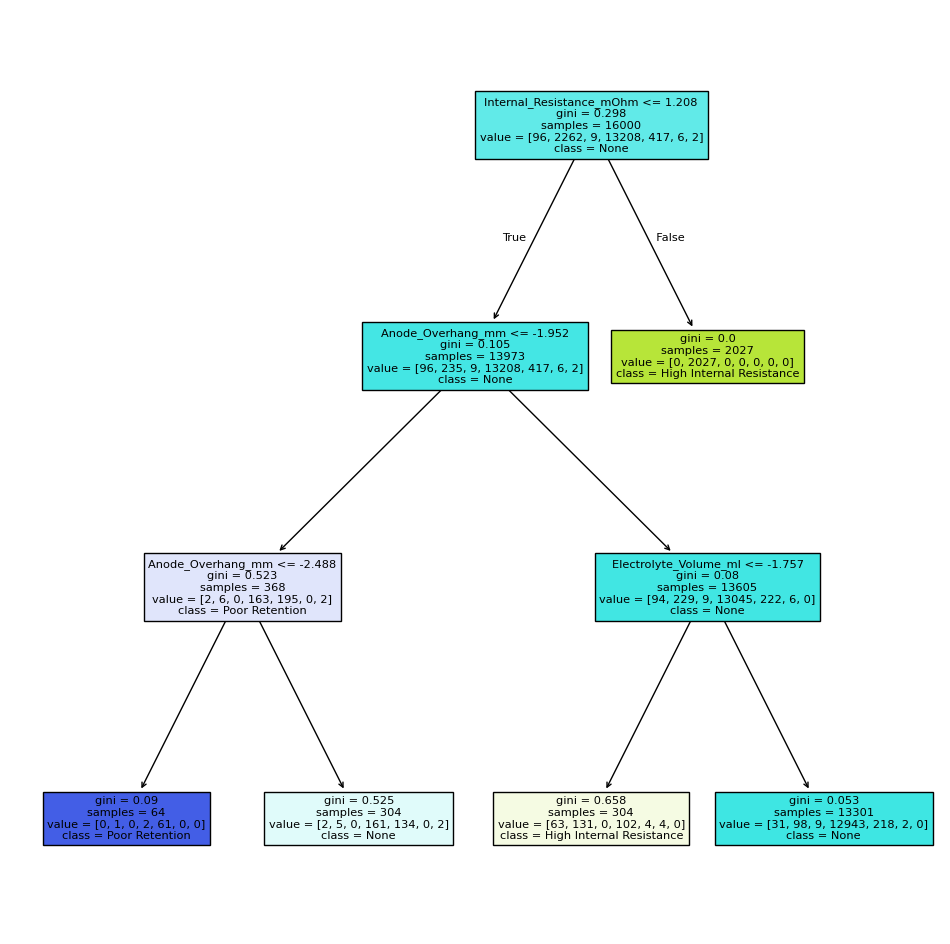

In [45]:
plt.figure(figsize=(12,12))
plot_tree(dt_model, feature_names=x.columns, class_names=["Critical Resistance", "High Internal Resistance", "Low Capacity", "None", 
                                                          "Poor Retention", "Severe Capacity Fade", "Short Circuit Risk (Overhang)"], filled=True)
plt.show()

## Model Training and Evaluation
#### Algorithim 4 - Random Forest 

In [46]:
rmf = RandomForestClassifier()
rmf_model = rmf.fit(xtrain, ytrain)
rmf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
ytrain_pred_rmf = rmf_model.predict(xtrain)
ytest_pred_rmf = rmf_model.predict(xtest)

In [48]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_rmf)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_rmf)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_rmf, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 1.0
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   96     0     0     0     0     0     0]
 [    0  2262     0     0     0     0     0]
 [    0     0     9     0     0     0     0]
 [    0     0     0 13208     0     0     0]
 [    0     0     0     0   417     0     0]
 [    0     0     0     0     0     6     0]
 [    0     0     0     0     0     0     2]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score  

In [49]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_rmf)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_rmf)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_rmf, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9705
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   2   19    0    0    0    0    0]
 [   7  563    0    5    0    0    0]
 [   0    0    0    2    0    0    0]
 [   0    2    0 3264   25    0    0]
 [   0    0    0   55   52    0    0]
 [   1    1    0    0    0    0    0]
 [   0    1    0    0    0    0    1]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.20      0.10    

## Model Training and Evaluation
#### Algorithim 5 - Adaboost Classifier

In [50]:
adc = AdaBoostClassifier()
adc_model = adc.fit(xtrain, ytrain)
adc_model

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [51]:
ytrain_pred_adc = adc_model.predict(xtrain)
ytest_pred_adc = adc_model.predict(xtest)

In [52]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_adc)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_adc)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_adc, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.962
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[    0    73     0    23     0     0     0]
 [    0  2169     0    93     0     0     0]
 [    0     0     0     9     0     0     0]
 [    1     4     0 13155    48     0     0]
 [    0     1     0   348    68     0     0]
 [    0     6     0     0     0     0     0]
 [    0     1     0     1     0     0     0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score

In [53]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_adc)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_adc)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_adc, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.96025
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   0   17    0    4    0    0    0]
 [   0  557    0   18    0    0    0]
 [   0    0    0    2    0    0    0]
 [   0    2    0 3268   21    0    0]
 [   0    0    0   91   16    0    0]
 [   0    2    0    0    0    0    0]
 [   0    1    0    1    0    0    0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.00      0.00   

## Model Training and Evaluation
#### Algorithim 6 - Gradient Boosting

In [54]:
gdb = GradientBoostingClassifier()
gdb_model = gdb.fit(xtrain, ytrain)
gdb_model

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [55]:
ytrain_pred_gdb = gdb_model.predict(xtrain)
ytest_pred_gdb = gdb_model.predict(xtest)

In [56]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_gdb)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_gdb)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_gdb, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9829375
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   53    43     0     0     0     0     0]
 [    4  2251     0     4     3     0     0]
 [    0     0     9     0     0     0     0]
 [    0     0     0 13180    28     0     0]
 [    0     0     0   190   227     0     0]
 [    0     0     0     0     0     6     0]
 [    0     1     0     0     0     0     1]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-s

In [57]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_gdb)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_gdb)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_gdb, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9705
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   3   18    0    0    0    0    0]
 [   9  561    0    4    1    0    0]
 [   0    0    0    2    0    0    0]
 [   0    5    0 3261   25    0    0]
 [   0    0    0   50   57    0    0]
 [   1    1    0    0    0    0    0]
 [   0    2    0    0    0    0    0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.23      0.14    

## Model Training and Evaluation
#### Algorithim 7 - XG Boost

In [58]:
xgb = XGBClassifier()
xgb_model = xgb.fit(xtrain, ytrain)
xgb_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [59]:
ytrain_pred_xgb = xgb_model.predict(xtrain)
ytest_pred_xgb = xgb_model.predict(xtest)

In [60]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_xgb)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_xgb)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_xgb, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 1.0
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   96     0     0     0     0     0     0]
 [    0  2262     0     0     0     0     0]
 [    0     0     9     0     0     0     0]
 [    0     0     0 13208     0     0     0]
 [    0     0     0     0   417     0     0]
 [    0     0     0     0     0     6     0]
 [    0     0     0     0     0     0     2]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score  

In [61]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_xgb)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_xgb)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_xgb, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.97025
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   3   18    0    0    0    0    0]
 [   9  561    0    5    0    0    0]
 [   0    0    0    2    0    0    0]
 [   0    3    0 3261   27    0    0]
 [   0    0    1   50   56    0    0]
 [   1    1    0    0    0    0    0]
 [   0    2    0    0    0    0    0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.23      0.14   

## Model Training and Evaluation
#### Algorithim 8 - SVM

In [62]:
svm = SVC()
svm_model = svm.fit(xtrain, ytrain)
svm_model

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [63]:
ytrain_pred_svm = svm_model.predict(xtrain)
ytest_pred_svm = svm_model.predict(xtest)

In [64]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_svm)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_svm)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_svm, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9550625
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[    0    44     0    52     0     0     0]
 [    0  2052     0   208     2     0     0]
 [    0     0     0     9     0     0     0]
 [    0    66     0 13134     8     0     0]
 [    0    11     0   311    95     0     0]
 [    0     3     0     3     0     0     0]
 [    0     0     0     2     0     0     0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-s

In [65]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_svm)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_svm)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_svm, zero_division=0)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9495
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[   0   12    0    9    0    0    0]
 [   0  517    0   58    0    0    0]
 [   0    0    0    2    0    0    0]
 [   0   25    0 3264    2    0    0]
 [   0    4    0   86   17    0    0]
 [   0    0    0    2    0    0    0]
 [   0    0    0    1    1    0    0]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.00      0.00    

## Saving Best Model in Pickle File

In [66]:
filename = "EV_Battery_QA_ML_Model(C).pkl"

with open(filename, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Model saved to {filename}")

Model saved to EV_Battery_QA_ML_Model(C).pkl
